=== Phase 3 Started ===

New detected structures: 48
Official building footprints: 86977
Zoning polygons: 44548

Structures already in official dataset: 2
Potential unauthorized (NOT in official records): 46


C:\Users\david\AppData\Local\Temp\ipykernel_6744\3074160244.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\david\AppData\Local\Temp\ipykernel_6744\3074160244.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


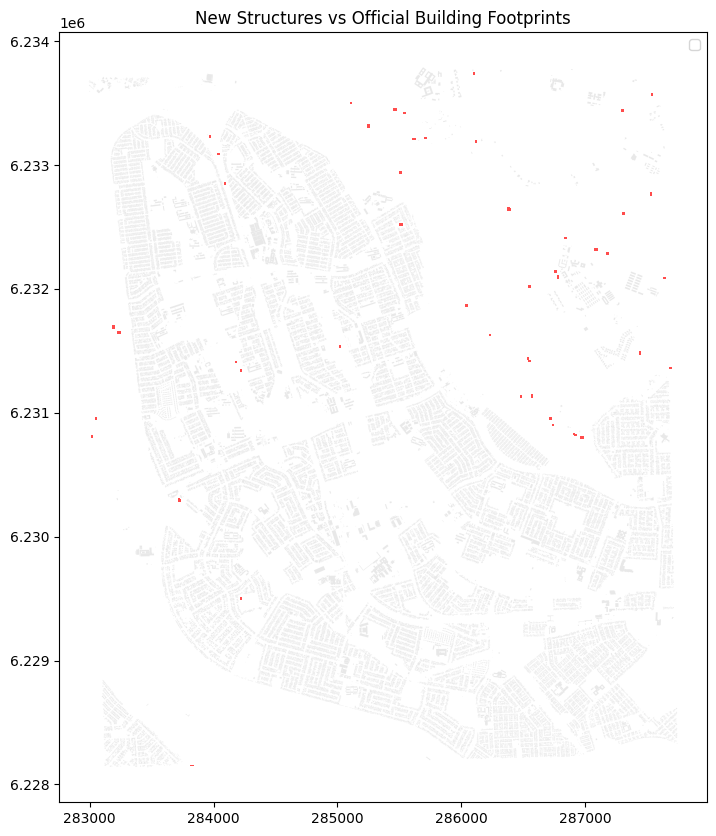


Ready for full compliance rule engine (zoning overlay + flagging).


In [1]:
# Overlay and Compliance Rule Engine

import geopandas as gpd
import matplotlib.pyplot as plt

print("=== Phase 3 Started ===\n")

# Load layers (all in UTM 34S)
new_structures = gpd.read_file("new_structures_final.geojson")
buildings     = gpd.read_file("buildings_khayelitsha_utm34.geojson")
zoning        = gpd.read_file("zoning_khayelitsha_utm34.geojson")

print(f"New detected structures: {len(new_structures)}")
print(f"Official building footprints: {len(buildings)}")
print(f"Zoning polygons: {len(zoning)}")

# Spatial join: Which new structures overlap with official buildings?
joined = gpd.sjoin(new_structures, buildings, how="left", predicate="intersects")

new_structures["in_official_records"] = ~joined["index_right"].isna()

print(f"\nStructures already in official dataset: {new_structures['in_official_records'].sum()}")
print(f"Potential unauthorized (NOT in official records): {len(new_structures) - new_structures['in_official_records'].sum()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
buildings.plot(ax=ax, color='lightgray', alpha=0.5, label="Official Buildings")
new_structures[~new_structures["in_official_records"]].plot(ax=ax, color='red', alpha=0.7, label="Potential Unauthorized")
ax.set_title("New Structures vs Official Building Footprints")
ax.legend()
plt.show()

print("\nReady for full compliance rule engine (zoning overlay + flagging).")

In [ ]:
# Compliance Engine 

import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

print("Running compliance engine...\n")

# Load layers
df = gpd.read_file("compliance_results_enhanced.geojson")
buildings = gpd.read_file("buildings_khayelitsha_utm34.geojson")
roads = gpd.read_file("roads_osm.geojson")

TARGET_CRS = "EPSG:32734"
df = df.to_crs(TARGET_CRS)
buildings = buildings.to_crs(TARGET_CRS)
roads = roads.to_crs(TARGET_CRS)


# Filter roads 
relevant_roads = roads[roads.get("highway", "").isin([
    "primary", "secondary", "tertiary", "residential"
])].copy()

print(f"Filtered roads: {len(relevant_roads)} segments")


# Compactness filter
df["compactness"] = 4 * np.pi * df.area / (df.length ** 2)
df = df[df["compactness"] > 0.25].copy().reset_index(drop=True)


# Road distance 
sindex_roads = relevant_roads.sindex

def min_road_distance(geom):
    possible_idx = list(sindex_roads.intersection(geom.bounds))
    if not possible_idx:
        return np.nan   
    possible_roads = relevant_roads.iloc[possible_idx]
    return possible_roads.distance(geom).min()

df["dist_to_road_m"] = df.geometry.apply(min_road_distance)


# Nearest building distance
nearest = gpd.sjoin_nearest(
    df[['geometry']], 
    buildings[['geometry']], 
    how="left", 
    distance_col="dist_to_existing_m"
)

df["dist_to_existing_m"] = nearest["dist_to_existing_m"].values

print(f"Distance to buildings → Min: {df['dist_to_existing_m'].min():.1f}m | Mean: {df['dist_to_existing_m'].mean():.1f}m")


# Clustering
coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in df.geometry])

clustering = DBSCAN(eps=60, min_samples=2).fit(coords)
df["cluster_id"] = clustering.labels_

cluster_sizes = pd.Series(df["cluster_id"]).value_counts()

def get_cluster_size(cid):
    if cid == -1:
        return 1
    return cluster_sizes.get(cid, 1)

df["cluster_size"] = df["cluster_id"].apply(get_cluster_size)
df["cluster_risk"] = np.log1p(df["cluster_size"]) / np.log1p(5)


# Road risk 
df["road_risk"] = np.exp(-df["dist_to_road_m"].fillna(200) / 50)


# Final risk score
df["final_risk_score"] = (
    df["risk_score"] * 0.5 +
    df["road_risk"] * 0.25 +
    df["cluster_risk"] * 0.25
).round(2)


# Growth type
def growth_type(row):
    d = row["dist_to_existing_m"]
    if pd.isna(d):
        return "Isolated / No Nearby Buildings"
    elif d < 15:
        return "Infill (very close)"
    elif d < 50:
        return "Edge Expansion"
    else:
        return "New Settlement / Sprawl"

df["growth_type"] = df.apply(growth_type, axis=1)


# Risk category
def risk_category(score):
    if score >= 0.65:      
        return "Critical"
    elif score >= 0.50:
        return "High"
    elif score >= 0.30:
        return "Moderate"
    else:
        return "Low"

df["risk_category"] = df["final_risk_score"].apply(risk_category)


# Sort results
df = df.sort_values("final_risk_score", ascending=False).reset_index(drop=True)


# Summary
print(f"\nFinal structures: {len(df)}")

print("\nCompliance Summary:")
print(df["compliance_status"].value_counts())

print("\nRisk Category:")
print(df["risk_category"].value_counts())

print("\nGrowth Type:")
print(df["growth_type"].value_counts())

print("\nCluster Size Distribution:")
print(df["cluster_size"].value_counts().sort_index())

print("\nTop 10 Highest Risk Structures:")
print(df.head(10)[[
    "area_m2", "INT_ZONE_DESC", "compliance_status",
    "final_risk_score", "risk_category",
    "growth_type", "dist_to_road_m",
    "dist_to_existing_m", "cluster_size"
]])


# Save
df.to_file("compliance_results_ultimate_final.geojson", driver="GeoJSON")

df.drop(columns=['geometry']).to_csv(
    "compliance_summary_ultimate_final.csv",
    index=False
)

print("\nSaved final files:")
print("   - compliance_results_ultimate_final.geojson")
print("   - compliance_summary_ultimate_final.csv")


# Visualization
fig, ax = plt.subplots(figsize=(14, 10))

df.plot(
    column="final_risk_score",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.85
)

ax.set_title("Risk Map")

plt.show()

Running compliance engine...



DataSourceError: roads_osm.geojson: No such file or directory